# Example 6: GNSS Sidelobe Pseudorange + Doppler + TDCP ODTS with an EKF

This tutorial turns the link-geometry products from Example 5 into an orbit-determination and time-synchronization problem. A lunar-orbiting receiver estimates its position, velocity, clock bias, clock drift, and solar-radiation-pressure coefficient using weak Earth-GNSS sidelobe signals.

The measurement model combines three observables:

$$
\rho_k = \|\mathbf r_{rx,k}-\mathbf r_{tx,k}\| + c\,b_k + \Delta_{rel,k}+\Delta_{plasma,k}+\epsilon_{\rho,k},
$$

the instantaneous Doppler (range rate), which constrains velocity and clock drift within a single epoch,

$$
\dot\rho_k = \frac{(\mathbf r_{rx,k}-\mathbf r_{tx,k})\cdot(\mathbf v_{rx,k}-\mathbf v_{tx,k})}{\|\mathbf r_{rx,k}-\mathbf r_{tx,k}\|} + c\,\dot b_k + \epsilon_{\dot\rho,k},
$$

and time-differenced carrier phase (TDCP), which approximately measures the change in range between consecutive epochs:

$$
\Delta\Phi_k \approx [\rho_k-\rho_{k-1}] + \epsilon_{\Delta\Phi,k}.
$$

Because TDCP references two epochs, the filter uses a stochastic-cloning UDU EKF: the augmented state carries both the current and previous receiver state so the TDCP Jacobian can be formed consistently. This is the main mathematical lesson of the notebook.

The workflow is staged:

1. precompute GNSS (GPS + Galileo) visibility, antenna gain, and $C/N_0$;
2. precompute plasmaspheric delay with GCPM/IRI2007 ray tracing on a coarse cadence and interpolate it to 1 Hz;
3. run the EKF and inspect orbit, clock, and SRP-coefficient errors.

Truth pseudoranges include the Sun's Shapiro delay and the GCPM/IRI2007 plasmaspheric delay. The filter models the (small, deterministic) Shapiro delay directly and cancels the first-order plasma delay with the dual-frequency ionosphere-free (L1+L5 / E1+E5a) combination rather than modeling the plasma explicitly; the residual is absorbed through pseudorange measurement-noise inflation. TDCP defaults to single-frequency (L1) carrier phase, so it does **not** get that cancellation — the truth carrier keeps the full plasmaspheric delay, and its epoch-to-epoch change (RMS ~3.6 cm, tail to ~0.85 m) is a real error the filter never models. TDCP's noise is therefore inflated well past raw carrier precision (`filter_tdcp_noise_inflation_m = 0.20 m`) so the EKF stays consistent instead of chasing that delay change as if it were state error; **§7c** derives this from the data and compares against the ionosphere-free-TDCP alternative (`tdcp_ionosphere_free`).

**Broadcast vs. precise transmitter ephemeris.** A real receiver corrects each GNSS transmitter's position and clock with the *broadcast* navigation message, not the precise post-processed product. This notebook models that gap: the truth measurements use the precise SP3 transmitter states, while the filter's measurement model is fed the **broadcast (RINEX-nav) position and clock**, evaluated live from the navigation-message parameters at each signal transmit epoch (`constellation.use_broadcast_ephemeris`). Before injection, the broadcast-minus-precise error is debiased — the per-constellation systematic clock offset (median over all satellites and epochs) and, for QZSS, the per-satellite radial-orbit offset are removed, following the CNAV broadcast-ephemeris evaluation of Montenbruck & Steigenberger (*J. Navigation*, 2018). The remaining ~1 m orbit / ~few-ns clock prediction error enters the filter as an unmodeled measurement error, so the ODTS solution reflects the broadcast-ephemeris uncertainty a lunar receiver actually faces rather than an idealized perfect-ephemeris case.

The precompute stages write CSV caches under `output/python_examples/ex6_gnss_odts_data/`. Delete that directory to regenerate all deterministic products.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Make *this* repo's pylupnt import cleanly, regardless of a global PYTHONPATH (e.g. an
# `export PYTHONPATH=.../some-other/python` in ~/.zshrc) or a reverted Jupyter kernelspec.
# Walk up from the working dir to the repo root (the dir holding python/pylupnt/) and:
#   1. put its python/ first on sys.path so `import pylupnt` finds this build, and
#   2. pin LUPNT_DATA_PATH so pylupnt uses this repo's data and skips its bootstrap
#      download-on-import.
# This cell must run before any other pylupnt import (restart the kernel if it already ran). ---
for _base in [Path.cwd(), *Path.cwd().parents]:
    if (_base / "python" / "pylupnt" / "__init__.py").exists():
        _local_python = str((_base / "python").resolve())
        if _local_python in sys.path:
            sys.path.remove(_local_python)
        sys.path.insert(0, _local_python)
        if (_base / "data" / "LuPNT_data" / "ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str(
                (_base / "data" / "LuPNT_data").resolve()
            )
        break

import pylupnt as pnt

print(f"pylupnt loaded from: {pnt.__file__}")
assert hasattr(pnt, "LunarGnssODTSConfig"), (
    "Loaded a stale pylupnt without LunarGnssODTSConfig -- restart the kernel so this cell "
    "runs first, or rebuild this repo's bindings with `pixi run build-py`."
)

[00.01][PyLuPNT] Initializing


pylupnt loaded from: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/python/pylupnt/__init__.py


## 1. Simulation configuration

`LunarGnssODTSConfig` is the Python-facing configuration for the same C++ simulation engine used by LuPNT's staged GNSS filtering pipeline. It defines the truth ELFO, the filter's reduced dynamics model, receiver-clock process noise, GNSS link-budget settings, plasma-delay options, and EKF tuning.

A key tutorial point is that the filter is intentionally imperfect: truth includes higher-fidelity dynamics and media effects, while the estimator uses a simpler onboard-style model. The measurement covariance is therefore inflated beyond raw tracking precision so the EKF does not chase unmodeled dynamics or plasma delay as if they were real state error.

In [2]:
# The scenario lives in `configs/lunar_gnss_odts.yaml` -- the thin agent-based architecture:
# a physical `receiver` Spacecraft hosting a `LunarGnssOdtsApp` (mirroring ex8). It is
# loaded and path-patched by `ex6_gnss_odts_config.load_scenario()`. Its application-block
# scalar values mirror `build_config()` (the struct config still used by the standalone
# precompute + the Stage 2 plasma ray-trace below) field-for-field, so the C++ precompute cache
# -- keyed on a fingerprint of the config -- is shared between this notebook and
# `ex6_precompute.py`. Edit the YAML (or that module) to change the scenario.
from ex6_gnss_odts_config import (
    build_config,
    load_scenario,
    describe,
    DATA_DIR,
    OUTPUT_DIR,
    PLASMA_DELAY_DT_S,
)

cfg = build_config()          # struct config: drives the Stage 2 plasma ray-trace below
scen = load_scenario()        # agent-based scenario dict for pnt.Simulation
sim = pnt.Simulation(scen)
app = sim.get_agent("receiver").get_application()
print(describe(cfg))

Configured 13.19-h run (~1 ELFO orbital period, 47475 s) at 1 Hz starting 2026-01-01T02:00:00
  TDCP on, SRP-coeff estimation on (truth Cr*A/m = 2.00e-3 m^2/kg)
  Pseudorange: ionosphere-free (L1+L5), C/N0 noise + filter inflation (PR 10 m, TDCP 50 mm)
  Tangent-altitude cutoff: PR >= 1000 m, TDCP >= 4000 m
  Constellation: GPS + Galileo, receiver antenna moongpsr, C/N0 gate 22/20 dB-Hz (acquisition/tracking)
  Plasma delay ray-traced every 120 s, interpolated to 1 Hz; progress every 10 rays
  EKF run progress every 1000 epochs (1000 s)
Data directory: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex6_gnss_odts_data


[01.64][/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/data/LuPNT_data/output/lunar_gnss_odts/lunar_gnss_odts.h5] Output file: {}
[01.64][Simulation] Output file: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/data/LuPNT_data/output/lunar_gnss_odts/lunar_gnss_odts.h5
[01.64][Simulation] Log level set to INFO
[02.25][Agent] No frequency set for lunar_gnss_odts/receiver
[02.25][Simulation] Saved config to /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/data/LuPNT_data/output/lunar_gnss_odts/config.yaml


## 2. Stage 1 & 2 — Precompute (run the script first!)

Stage 1 (link geometry) and Stage 2 (plasmaspheric ray tracing) are the slow part of this
example and are painful to run inside a notebook. **Run them once from a terminal:**

```bash
pixi run python ex6_precompute.py          # generate the cache (Stage 1 + Stage 2)
pixi run python ex6_precompute.py --force  # wipe and regenerate
```

That uses the exact same config as this notebook (both call
`ex6_gnss_odts_config.build_config`), so afterwards the two cells below are just fast cache
reads. `sim.precompute()` propagates the truth ELFO trajectory, builds the GPS+Galileo
constellation, solves visibility/light-time, and writes every tracked link to
`config.links_file`; the C++ side caches it by fingerprinting the config, so re-running is a
no-op once the script has produced it. (If you skip the script, the cells still work — they
just do the slow work in-notebook.)

In [3]:
t0 = time.time()
app.precompute()  # Stage 1: build GNSS link geometry / C-N0 -> precomputed_links.csv cache
print(f"precompute() took {time.time() - t0:.1f} s")

links = pd.read_csv(cfg.links_file)
print(
    f"{len(links)} receiver-satellite-frequency links across "
    f"{links['epoch_index'].nunique()} epochs "
    f"({links.groupby('epoch_index').size().mean():.1f} links/epoch on average)"
)
links.head()

precompute() took 0.0 s
[02.26][LunarGnssODTS] Using cached GNSS link precompute: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex6_gnss_odts_data/precomputed_links.csv


451327 receiver-satellite-frequency links across 47475 epochs (9.5 links/epoch on average)


,link_id,epoch_index,t_tdb,t_utc,gnss_const_id,gnss_const,prn,frequency_id,frequency,rx_x_ecef_m,...,cn0_dbhz,ionosphere_plasma_delay_m,tecu,tec_delay_m,second_delay_m,third_delay_m,dist_bend_m,tec_delay_bend_m,max_sep_line_m,final_pos_err_m
0,0,0,8.205049e+08,820504800.0,0,GPS,10,0,L1,1.342416e+08,...,37.319690,0,0,0,0,0,0,0,0,0
1,1,0,8.205049e+08,820504800.0,0,GPS,27,0,L1,1.342416e+08,...,37.601015,0,0,0,0,0,0,0,0,0
2,2,0,8.205049e+08,820504800.0,0,GPS,10,2,L5,1.342416e+08,...,42.856147,0,0,0,0,0,0,0,0,0
3,3,0,8.205049e+08,820504800.0,0,GPS,26,2,L5,1.342416e+08,...,26.184841,0,0,0,0,0,0,0,0,0
4,4,0,8.205049e+08,820504800.0,0,GPS,27,2,L5,1.342416e+08,...,43.137472,0,0,0,0,0,0,0,0,0


## 3. Stage 2 — Precompute Plasmaspheric Delay (GCPM/IRI2007 Ray Trace)

This mirrors `projects/GNSS_Filtering/precompute_delays.py`: `pnt.trace_ray` integrates the
GCPM/IRI2007 electron-density model along the transmitter-receiver line of sight and returns
the total electron content (TEC) delay plus higher-order (2nd/3rd) ionospheric terms.

Ray tracing is the slow step (one trace per link), and at 1 Hz over a full orbital period
there are far too many links to trace directly. Instead, this stage **ray-traces only
"anchor" epochs on a `PLASMA_DELAY_DT_S` = 120 s cadence and linearly interpolates each
satellite-frequency link's delay in time to the 1 Hz schedule** — the receiver's sidelobe
geometry, and hence the plasmaspheric path, varies slowly enough over two minutes for
linear interpolation to be accurate. This cuts the trace count by roughly the cadence
factor (~120×). A satellite whose entire pass falls between two anchors (shorter than the
cadence) has no anchor to interpolate from and is traced directly as a fallback, so a real
delay is never silently zeroed.

The remaining anchor traces are **run in parallel across processes** with a
`multiprocessing` **fork** pool (`N_DELAY_WORKERS` = `os.cpu_count()`). Ray tracing is
CPU-bound and each trace is independent, so this scales ~linearly with cores. A *fork*
context is used deliberately: each worker then inherits the parent's already-configured
`rt_config` and `pnt` module, and the notebook-scope worker function resolves in the child
(the default *spawn* start method on some platforms cannot pickle functions defined in a
notebook cell). Results are cached to `config.delays_file` — which stores a delay for
*every* 1 Hz link, so the C++ engine reads it unchanged — and reused on subsequent runs.

In [4]:
# Stage 2 (plasmaspheric ray tracing) is slow. Prefer running it once from a terminal:
#     pixi run python ex6_precompute.py
# Then this cell just loads the cached CSV. If the cache is missing, it falls back to the
# same `compute_delays` the script uses (which will be slow inside the notebook).
from ex6_precompute import compute_delays, delays_cache_valid

delays_path = Path(cfg.delays_file)
if delays_cache_valid(cfg, PLASMA_DELAY_DT_S):
    print(f"Reusing cached plasma delays (settings match): {delays_path}")
    delays = pd.read_csv(delays_path)
else:
    print(
        "No up-to-date cached delays for these settings -- ray-tracing now (slow in a "
        "notebook; prefer `pixi run python ex6_precompute.py` in a terminal)."
    )
    delays = compute_delays(cfg, links, PLASMA_DELAY_DT_S)

print(
    f"Plasma delay range: {delays['ionosphere_plasma_delay_m'].min():.2f} - "
    f"{delays['ionosphere_plasma_delay_m'].max():.2f} m"
)

Reusing cached plasma delays (settings match): /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex6_gnss_odts_data/precomputed_delays.csv


Plasma delay range: 0.00 - 133.91 m


### Sanity check: delay vs. ray tangent altitude

The plasmaspheric delay should fall off roughly monotonically as the signal path's tangent
point rises away from the denser plasmasphere near Earth.

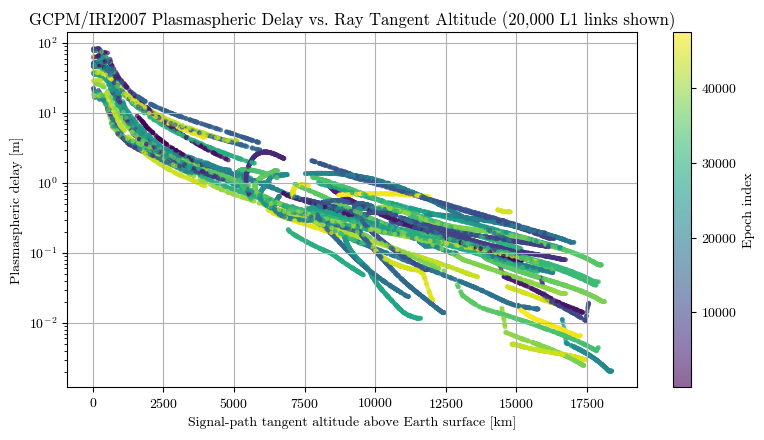

In [5]:
# Sanity check plots only the ray-traced L1 links (the ones carrying a real plasma delay).
# The full-orbit `delays` table has hundreds of thousands of rows -- mostly zero-delay
# L5/Galileo/occulted links -- and scattering all of them overwhelms matplotlib's Agg
# renderer ("OverflowError: Exceeded cell block limit"). Filter to L1, non-occulted, and cap
# the marker count.
plot_df = delays[(delays["frequency"] == "L1") & (delays["tangent_altitude_m"] >= 0.0)]
plot_df = plot_df[
    plot_df[["tangent_altitude_m", "ionosphere_plasma_delay_m"]].notna().all(axis=1)
]
MAX_MARKERS = 20000
if len(plot_df) > MAX_MARKERS:
    plot_df = plot_df.sample(MAX_MARKERS, random_state=0)

fig, ax = plt.subplots(figsize=(8, 4.5))
sc = ax.scatter(
    plot_df["tangent_altitude_m"] / 1e3,
    plot_df["ionosphere_plasma_delay_m"],
    s=6,
    c=plot_df["epoch_index"],
    cmap="viridis",
    alpha=0.6,
)
ax.set_xlabel("Signal-path tangent altitude above Earth surface [km]")
ax.set_ylabel("Plasmaspheric delay [m]")
ax.set_title(
    f"GCPM/IRI2007 Plasmaspheric Delay vs. Ray Tangent Altitude "
    f"({len(plot_df):,} L1 links shown)"
)
plt.colorbar(sc, ax=ax, label="Epoch index")
ax.grid(True)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 4. Run the EKF

`sim.run()` reads `config.delays_file` (since `plasma.simulate_truth=True`), builds noisy
truth pseudorange, Doppler, and TDCP observations, and runs the UDU stochastic-cloning EKF
(because `use_tdcp=True`) over the full receiver-app schedule. It writes
`trajectory_mc0.csv` and `summary.csv` under `config.output_dir` and returns one
`LunarGnssODTSSummary` per Monte Carlo run.

In [6]:
t0 = time.time()
traj_file = Path(cfg.output_dir) / "trajectory_mc0.csv"
if traj_file.exists():
    print(f"Reusing cached trajectory: {traj_file}")
else:
    print(f"Running the EKF (agent-based LunarGnssOdtsApp); trajectory -> {traj_file}...")
    sim.run()
    print(f"run() took {time.time() - t0:.1f} s")

    summary = app.get_summaries()[0]
    print(f"Final position error:    {summary.final_position_error_m:8.3f} m")
    print(
        f"Final velocity error:    {summary.final_velocity_error_mps * 1e3:8.3f} mm/s"
    )
    print(f"Final clock bias error:  {summary.final_clock_bias_error_m * 1e2:8.3f} cm")
    print(
        f"Final clock drift error: {summary.final_clock_drift_error_mps * 1e3:8.3f} mm/s"
    )
    print(f"RMS position error:      {summary.rms_position_error_m:8.3f} m")
    print(f"RMS velocity error:      {summary.rms_velocity_error_mps * 1e3:8.3f} mm/s")
    if cfg.estimate_srp_coefficient:
        srp_est = cfg.srp_coeff_truth_m2_kg + summary.final_srp_coeff_error_m2_kg
        print(
            f"Final SRP coeff est:     {srp_est * 1e3:8.3f} e-3 m^2/kg "
            f"(truth {cfg.srp_coeff_truth_m2_kg * 1e3:.3f}e-3, "
            f"err {summary.final_srp_coeff_error_m2_kg * 1e3:+.3f}e-3)"
        )

traj = pd.read_csv(Path(cfg.output_dir) / "trajectory_mc0.csv")
traj["t_min"] = traj["t"] / 60.0
traj["t_hr"] = traj["t"] / 3600.0
traj.head()

Reusing cached trajectory: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex6_gnss_odts_data/trajectory_mc0.csv


,mc,t,receiver_clock_s,pos_error_m,vel_error_mps,x_error_m,y_error_m,z_error_m,vx_error_mps,vy_error_mps,...,clock_bias_3sigma_m,clock_drift_3sigma_mps,srp_coeff_est_m2_kg,srp_coeff_error_m2_kg,srp_coeff_3sigma_m2_kg,num_channels,num_tracked_satellites,num_measurements,t_min,t_hr
0,0,0,0.000002,153.776,0.106381,-78.4435,-130.408,22.0773,0.049280,0.092919,...,285.200,0.008994,0.000232,-0.001768,0.003,3,3,3,0.000000,0.000000
1,0,1,1.000000,153.680,0.080464,-75.6371,-131.810,22.8662,0.038385,0.070650,...,284.873,0.008992,0.000232,-0.001768,0.003,3,3,6,0.016667,0.000278
2,0,2,2.000000,152.077,0.069649,-72.3209,-132.167,20.7156,0.033581,0.060974,...,284.764,0.008991,0.000232,-0.001768,0.003,3,3,6,0.033333,0.000556
3,0,3,3.000000,149.580,0.064501,-64.5266,-133.852,17.1497,0.031202,0.056236,...,284.708,0.008991,0.000232,-0.001768,0.003,3,3,6,0.050000,0.000833
4,0,4,4.000000,152.950,0.060919,-76.7494,-130.493,21.7895,0.029448,0.052910,...,284.674,0.008991,0.000232,-0.001768,0.003,3,3,6,0.066667,0.001111


## 5. Position Error in the RTN Frame, with 3-sigma Bounds

`r`/`t`/`n` are the radial/transverse/normal components of the position error; the shaded
band is the filter's own formal 3-sigma envelope (`*_3sigma_m` columns), computed from the
EKF covariance at each epoch.

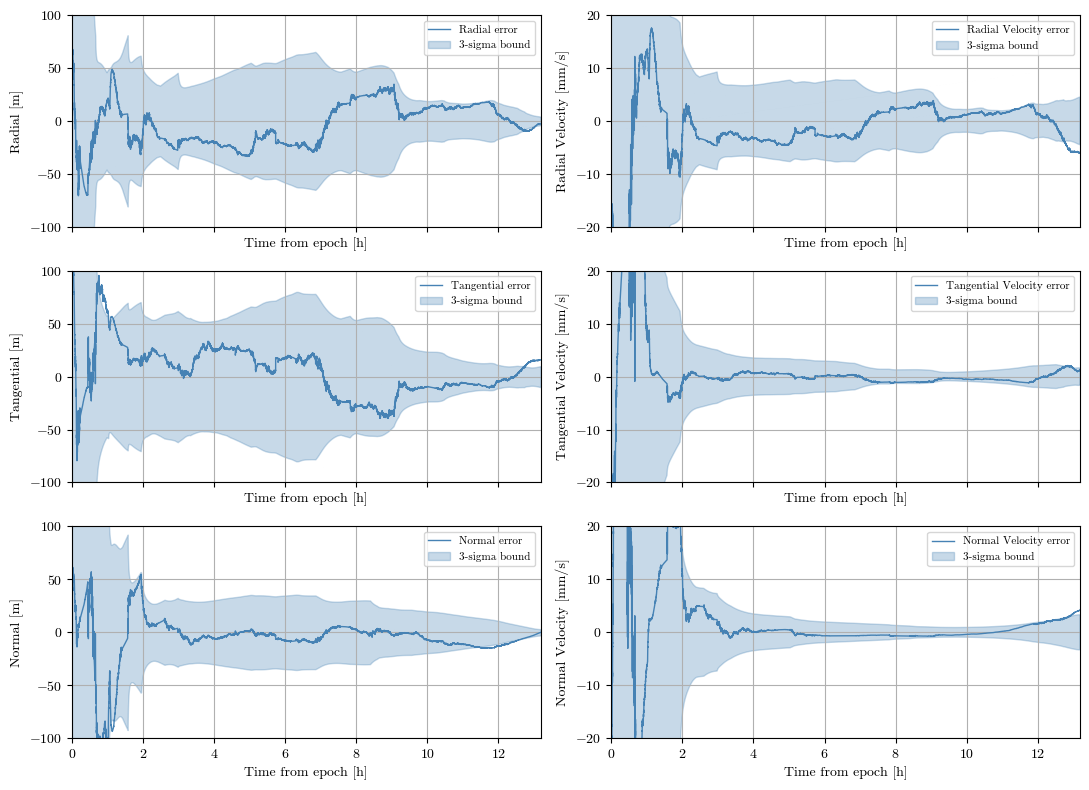

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)
for row, (key, name) in zip(
    [0, 1, 2, 0, 1, 2],
    [
        ("r", "Radial"),
        ("t", "Tangential"),
        ("n", "Normal"),
        ("rdot", "Radial Velocity"),
        ("tdot", "Tangential Velocity"),
        ("ndot", "Normal Velocity"),
    ],
):
    if key in ["r", "t", "n"]:
        col = 0
        suffix = "m"
        axes[row, col].set_ylim(-100, 100)
        scale = 1.0
        axes[row, col].set_ylabel(f"{name} [m]")
        axes[row, col].grid(True)
    else:
        col = 1
        suffix = "mps"
        axes[row, col].set_ylim(-20, 20)
        scale = 1000.0
        axes[row, col].set_ylabel(f"{name} [mm/s]")
        axes[row, col].grid(True)

    err = traj[f"{key}_error_{suffix}"]
    sig = traj[f"{key}_3sigma_{suffix}"]
    axes[row, col].plot(
        traj["t_hr"], err * scale, color="steelblue", lw=1.0, label=f"{name} error"
    )
    axes[row, col].fill_between(
        traj["t_hr"],
        -sig * scale,
        sig * scale,
        color="steelblue",
        alpha=0.3,
        label="3-sigma bound",
    )
    axes[row, col].legend(loc="upper right", fontsize=8)
    axes[row, col].set_xlabel("Time from epoch [h]")
    axes[row, col].set_xlim(0, traj["t_hr"].max())
plt.tight_layout()
plt.show()

## 6. Clock Bias and Drift Error

Clock errors are reported in range-equivalent units (`c * dt`), matching the pseudorange
measurement's own units.

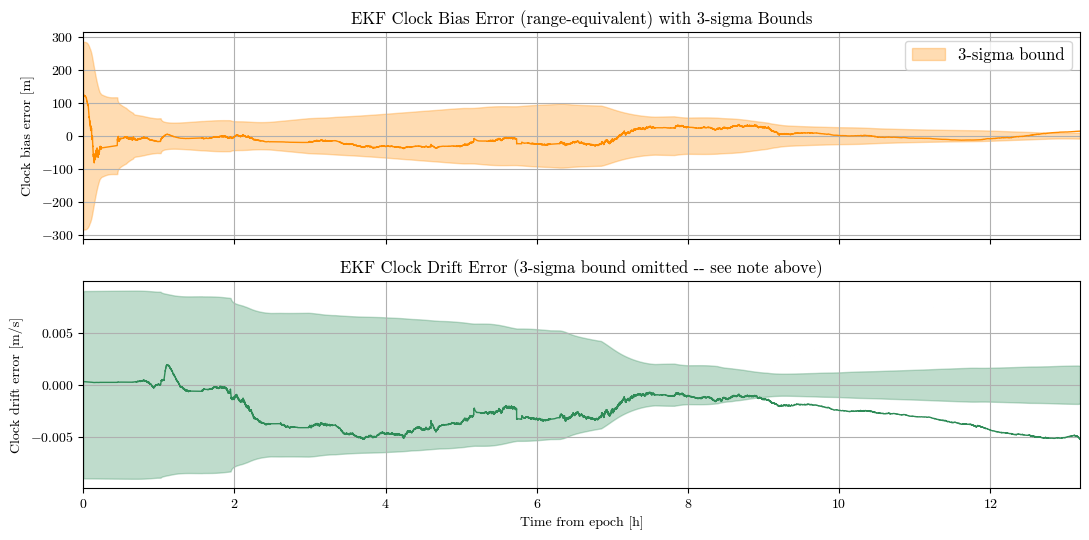

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)

axes[0].plot(traj["t_hr"], traj["clock_bias_error_m"], color="darkorange", lw=1.0)
axes[0].fill_between(
    traj["t_hr"],
    -traj["clock_bias_3sigma_m"],
    traj["clock_bias_3sigma_m"],
    color="darkorange",
    alpha=0.3,
    label="3-sigma bound",
)
axes[0].set_ylabel("Clock bias error [m]")
axes[0].set_title("EKF Clock Bias Error (range-equivalent) with 3-sigma Bounds")
axes[0].legend(loc="upper right", fontsize=12)
axes[0].grid(True)

# No 3-sigma shading here -- see the markdown note above on why clock_drift_3sigma_mps
# is not trustworthy (covariance conditioning, unrelated to TDCP).
axes[1].plot(traj["t_hr"], traj["clock_drift_error_mps"], color="seagreen", lw=1.0)
axes[1].fill_between(
    traj["t_hr"],
    -traj["clock_drift_3sigma_mps"],
    traj["clock_drift_3sigma_mps"],
    color="seagreen",
    alpha=0.3,
    label="3-sigma bound (not trustworthy -- see note above)",
)
axes[1].set_ylabel("Clock drift error [m/s]")
axes[1].set_title("EKF Clock Drift Error (3-sigma bound omitted -- see note above)")
axes[1].set_xlabel("Time from epoch [h]")
axes[1].set_xlim(0, traj["t_hr"].max())
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6b. Solar Radiation Pressure Coefficient Estimate

With `estimate_srp_coefficient=True`, the filter carries the SRP coefficient (`Cr*A/m`)
as a 9th state alongside orbit and clock. Its sensitivity is propagated **analytically**:
`LunarGnssOdtsApp` calls `NBodyDynamics::PropagateWithParams` on the C++
`JointOrbitClockState` with an SRP `ParamState`, so the epoch-to-epoch state-transition
matrix already contains the `∂x/∂(Cr*A/m)` param-partial block (`stm_param`) — there is
**no numerical differencing** of the dynamics to build the Jacobian.

The truth ELFO is perturbed with `srp_coeff_truth_m2_kg` while the filter starts from a
deliberately biased `initial_srp_coeff_m2_kg`; the plot below shows the estimate pulling
toward the dashed truth line. SRP is only weakly observable over a single orbit (it acts
as a slow, mostly along-track acceleration), so convergence is gradual and the formal
3-sigma band shrinks slowly — one orbital period is about the shortest useful arc for
seeing it move at all.

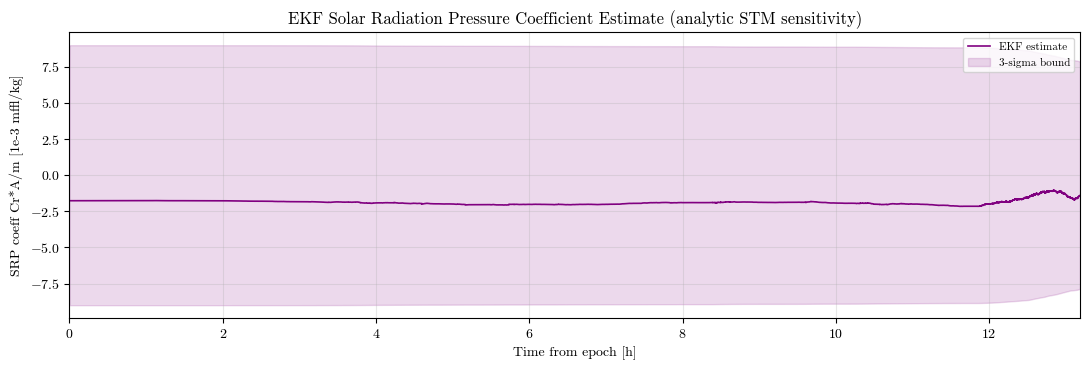

In [9]:
est = traj["srp_coeff_est_m2_kg"] * 1e3  # 1e-3 m^2/kg
true_val = cfg.srp_coeff_truth_m2_kg * 1e3  # 1e-3 m^2/kg
sig = traj["srp_coeff_3sigma_m2_kg"] * 1e3

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(traj["t_hr"], est - true_val, color="purple", lw=1.2, label="EKF estimate")
ax.fill_between(
    traj["t_hr"],
    -3 * sig,
    3 * sig,
    color="purple",
    alpha=0.15,
    label="3-sigma bound",
)
ax.set_xlabel("Time from epoch [h]")
ax.set_ylabel("SRP coeff Cr*A/m [1e-3 m²/kg]")
ax.set_title(
    "EKF Solar Radiation Pressure Coefficient Estimate (analytic STM sensitivity)"
)
ax.set_xlim(0, traj["t_hr"].max())
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6c. Error Distribution (True − Estimated)

Histograms of the per-epoch ephemeris error over the full run — radial / transverse /
normal position components and the range-equivalent clock bias — each annotated with mean,
standard deviation, and RMS. A well-tuned filter centers each distribution near zero with a
spread consistent with the 3-sigma envelopes in §5–6. This is the distribution over epochs
of a single Monte Carlo run; raise `cfg.monte_carlo_runs` for a cross-run distribution.

/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_87173/14268039.py:27: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  plt.tight_layout()
/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


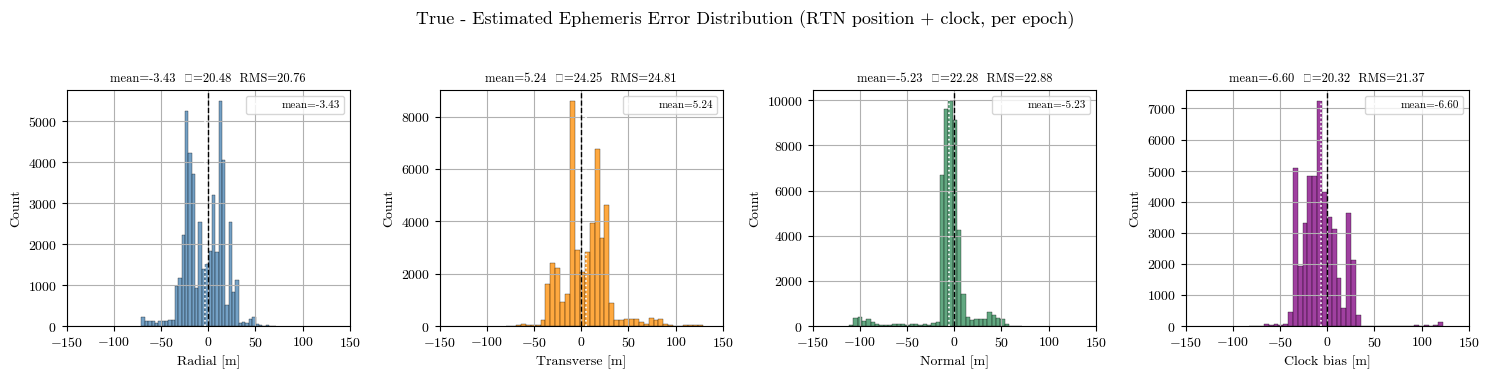

Component             mean       std       RMS  95th |err|
----------------------------------------------------------
Radial [m]          -3.432    20.476    20.761      32.842
Transverse [m]       5.241    24.253    24.813      47.331
Normal [m]          -5.226    22.279    22.884      51.633
Clock bias [m]      -6.600    20.323    21.368      33.949


In [10]:
dist_cols = [
    ("r_error_m", "Radial [m]", "steelblue"),
    ("t_error_m", "Transverse [m]", "darkorange"),
    ("n_error_m", "Normal [m]", "seagreen"),
    ("clock_bias_error_m", "Clock bias [m]", "purple"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (col, label, color) in zip(axes, dist_cols):
    data = traj[col].to_numpy()
    mean, std = float(np.mean(data)), float(np.std(data))
    rms = float(np.sqrt(np.mean(data**2)))
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="k", lw=0.3)
    ax.axvline(0.0, color="k", ls="--", lw=1.0)
    ax.axvline(mean, color="white", ls=":", lw=1.2, label=f"mean={mean:.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"mean={mean:.2f}  σ={std:.2f}  RMS={rms:.2f}", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True)
    ax.set_xlim(-150, 150)
fig.suptitle(
    "True - Estimated Ephemeris Error Distribution (RTN position + clock, per epoch)",
    y=1.04,
    fontsize=13,
)
plt.tight_layout()
plt.show()

print(f"{'Component':<16}{'mean':>10}{'std':>10}{'RMS':>10}{'95th |err|':>12}")
print("-" * 58)
for col, label, _ in dist_cols:
    d = traj[col].to_numpy()
    print(
        f"{label:<16}{np.mean(d):>10.3f}{np.std(d):>10.3f}{np.sqrt(np.mean(d**2)):>10.3f}"
        f"{np.percentile(np.abs(d), 95):>12.3f}"
    )

## 7. Sidelobe Tracking and TDCP Contribution

`num_tracked_satellites` is the number of distinct GNSS (GPS + Galileo) satellites tracked
via sidelobe reception at each epoch; `num_measurements` is the total measurement-row count
fed to the filter that epoch (pseudorange and Doppler rows plus one TDCP row per
continuously tracked link). The first epoch has no TDCP rows since there is no previous
epoch to difference against.

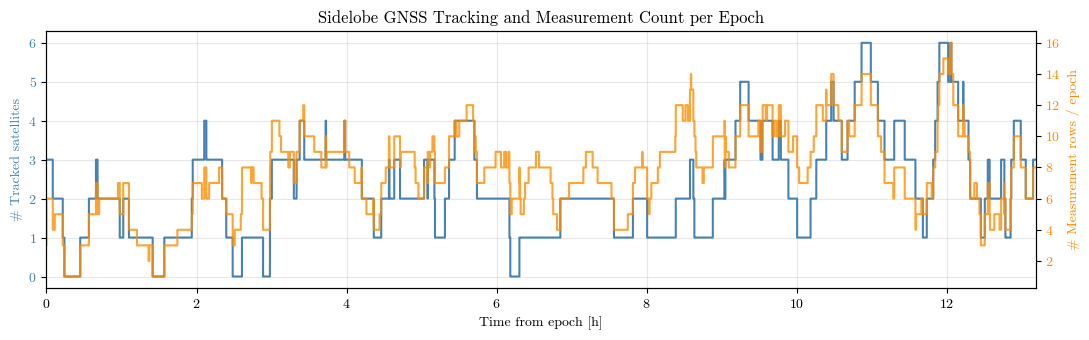

Epochs with at least one TDCP row: 47474/47475


In [11]:
fig, ax1 = plt.subplots(figsize=(11, 3.5))
ax1.step(
    traj["t_hr"],
    traj["num_tracked_satellites"],
    where="post",
    color="steelblue",
    label="Tracked GNSS satellites (sidelobe)",
)
ax1.set_xlabel("Time from epoch [h]")
ax1.set_ylabel("# Tracked satellites", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xlim(0, traj["t_hr"].max())

ax2 = ax1.twinx()
ax2.step(
    traj["t_hr"],
    traj["num_measurements"],
    where="post",
    color="darkorange",
    alpha=0.8,
    label="Measurement rows (pseudorange + Doppler + TDCP)",
)
ax2.set_ylabel("# Measurement rows / epoch", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.set_title("Sidelobe GNSS Tracking and Measurement Count per Epoch")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_tdcp_epochs = int((traj["num_measurements"] > traj["num_tracked_satellites"]).sum())
print(f"Epochs with at least one TDCP row: {n_tdcp_epochs}/{len(traj)}")

## 7c. Making TDCP consistent — the single-frequency plasma leak

TDCP is extremely precise (carrier phase, ~mm), so it is tempting to hand the filter a
correspondingly tight measurement noise. Doing so is a trap. **TDCP is single-frequency
(GPS L1 / Galileo E1), so unlike the pseudorange it gets no ionosphere-free cancellation:**
the truth carrier keeps the ray-traced plasmaspheric delay, and its *epoch-to-epoch change*
is a real error the filter never models (`plasma.model_in_filter=false`). Measured directly
from `precomputed_delays.csv` for this arc, that per-second delta is **RMS 3.6 cm, p95 1.9 cm,
p99 14 cm, with a tail to ~0.85 m** — three-plus orders of magnitude larger than the raw
carrier precision.

Feed TDCP at ~1 cm and the EKF treats those plasma-delta spikes as state error, chases them,
and the covariance collapses far below the true error — the classic *inconsistent* filter
(σ < error). The knob is `filter_tdcp_noise_inflation_m`. Sweeping it on the full 14 h arc
(single Monte-Carlo seed; *norm-err RMS* = RMS of error/σ per axis, ≈ 1 when consistent):

| configuration | TDCP meas/epoch | norm-err RMS (R/T/N) | pos RMS | final err |
|---|---|---|---|---|
| pseudorange only | 0 | 2.0 / 2.1 / 1.4 | 54.6 m | 23.2 m |
| **+ TDCP, inflation 1 cm** | 5.4 | **25 / 31 / 49** | **768 m** | 106 m |
| **+ TDCP, inflation 0.20 m** (default) | 5.4 | 1.6 / 1.6 / 1.6 | **39.6 m** | 16.1 m |

At 1 cm the filter diverges; at 0.20 m — which covers the plasma-delta distribution — TDCP is
as consistent as the pseudorange-only baseline *and* improves accuracy (pos RMS 54.6 → 39.6 m,
final 23.2 → 16.1 m). (Process noise is *not* the lever here: the solution is
measurement-dominated, and the residual ~1.6× overconfidence is a pre-existing baseline effect
present in the pseudorange-only case too.)

### Why not cancel the plasma with ionosphere-free TDCP?

The plasma delay is 99.96 % first-order, so an L1+L5 / E1+E5a *carrier* combination cancels it
to ~1 mm — exactly as the pseudorange does. Set `tdcp_ionosphere_free: true` to use it. But it
does **not** win in this scenario, for two compounding reasons:

1. **Coverage.** Ionosphere-free TDCP needs *both* frequencies on a satellite; single-frequency
   TDCP needs only L1. At this lunar sidelobe geometry far more satellites carry L1 than L1+L5,
   so IF-TDCP roughly **halves** the TDCP count (5.4 → 2.3 rows/epoch).
2. **The binding residual isn't the plasma.** Once plasma is cancelled, TDCP's precision exposes
   a *frequency-independent* residual — the broadcast-ephemeris error and its drift plus
   receiver-clock short-term noise (≈ 0.1–0.15 m equivalent, see §7b) — that IF **cannot** cancel
   and process noise cannot cover. So the inflation needed for consistency (~0.15–0.20 m) already
   exceeds the 3.6 cm plasma, and cancelling plasma buys nothing while the coverage loss hurts.

At equal 0.20 m inflation, IF-TDCP lands at pos RMS 51.1 m / final 19.7 m — worse than the
single-frequency 39.6 m / 16.1 m purely from the halved coverage. **Single-frequency TDCP with a
0.20 m inflation is the right choice here;** keep `tdcp_ionosphere_free` for regimes where the
plasma dominates (high solar activity, lower orbits, or tighter clocks) *and* dual-frequency
sidelobe coverage is good.


## 7b. Broadcast Ephemeris Error Distribution (true − broadcast)

Each epoch the run records, per tracked satellite, the two halves of the **broadcast (RINEX-nav)
signal-in-space error** the pseudorange actually sees, both as *true − broadcast*, to
`ephemeris_residuals_mc0.csv` (columns `mc, epoch, t_s, gnss, prn, eph_los_m, eph_clk_m`; the same
`eph_los_m`/`eph_clk_m` shown in the per-epoch measurement debug table):

- **`eph_los_m`** — the transmitter **orbit** (position) error projected onto the
  receiver→transmitter line of sight [m].
- **`eph_clk_m`** — the transmitter **clock** error in range units, $c\,\Delta t_{tx}$ [m].

Their sum is the total broadcast range error entering the pseudorange (the residual the filter must
absorb). All are deterministic, so identical across Monte-Carlo runs, and reflect the *residual*
error after the per-constellation clock (and QZSS radial) debiasing.

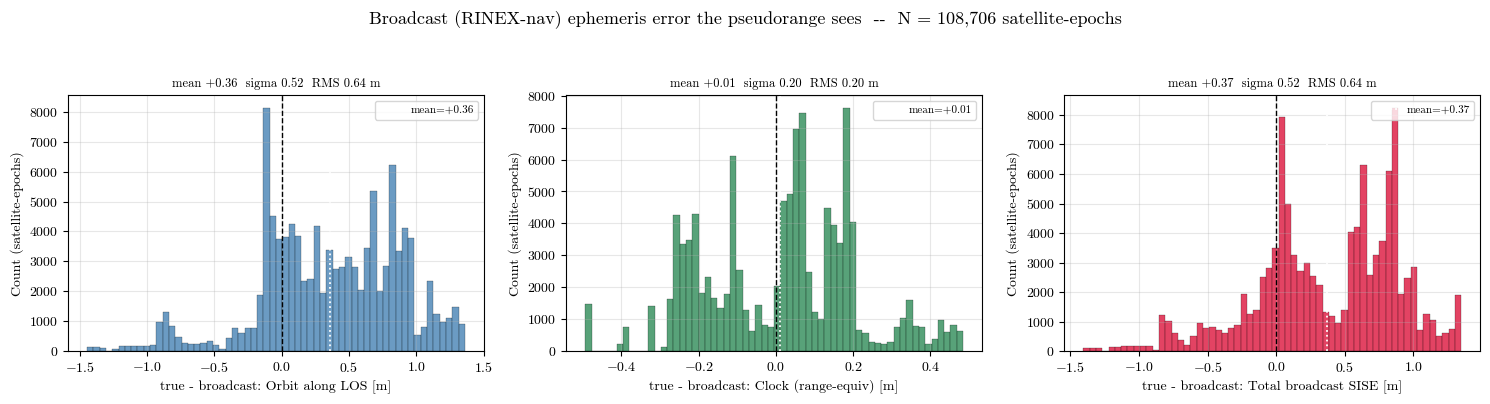

          component            N      mean       std       RMS   95th|.|
------------------------------------------------------------------------
GALILEO   Orbit along LOS   30315     0.030     0.155     0.158     0.345
GALILEO   Clock (range-equiv)   30315     0.146     0.150     0.209     0.451
GALILEO   Total broadcast SISE   30315     0.176     0.267     0.319     0.628
GPS       Orbit along LOS   78391     0.488     0.558     0.741     1.220
GPS       Clock (range-equiv)   78391    -0.041     0.188     0.192     0.343
GPS       Total broadcast SISE   78391     0.447     0.572     0.726     1.197


In [12]:
eph_path = Path(cfg.output_dir) / "ephemeris_residuals_mc0.csv"
if not eph_path.exists():
    print(
        f"{eph_path} not found -- run the EKF in section 4 (delete trajectory_mc0.csv to force a "
        "re-run) so it writes the per-satellite ephemeris residuals."
    )
else:
    eph = pd.read_csv(eph_path)
    # Both are (true - broadcast): orbit = transmitter position error along the line of sight,
    # clock = transmitter clock error in range units. `total` is their sum -- the broadcast
    # range error the pseudorange sees (the residual the filter must absorb, up to sign).
    eph["total_m"] = eph["eph_los_m"] + eph["eph_clk_m"]
    comps = [
        ("eph_los_m", "Orbit along LOS [m]", "steelblue"),
        ("eph_clk_m", "Clock (range-equiv) [m]", "seagreen"),
        ("total_m", "Total broadcast SISE [m]", "crimson"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    for ax, (col, label, color) in zip(axes, comps):
        d = eph[col].to_numpy()
        ax.hist(d, bins=60, color=color, alpha=0.8, edgecolor="k", lw=0.2)
        ax.axvline(0.0, color="k", ls="--", lw=1.0)
        ax.axvline(d.mean(), color="white", ls=":", lw=1.3, label=f"mean={d.mean():+.2f}")
        ax.set_xlabel(f"true - broadcast: {label}")
        ax.set_ylabel("Count (satellite-epochs)")
        ax.set_title(f"mean {d.mean():+.2f}  sigma {d.std():.2f}  RMS {np.sqrt(np.mean(d**2)):.2f} m",
                     fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"Broadcast (RINEX-nav) ephemeris error the pseudorange sees  --  "
                 f"N = {len(eph):,} satellite-epochs", y=1.05, fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"{'':<10}{'component':<14}{'N':>8}{'mean':>10}{'std':>10}{'RMS':>10}{'95th|.|':>10}")
    print("-" * 72)
    for g, sub in eph.groupby("gnss"):
        for col, label, _ in comps:
            v = sub[col].to_numpy()
            print(f"{g:<10}{label.split(' [')[0]:<14}{len(v):>8}{v.mean():>10.3f}{v.std():>10.3f}"
                  f"{np.sqrt(np.mean(v**2)):>10.3f}{np.percentile(np.abs(v), 95):>10.3f}")

## 7d. Monte Carlo — ensemble spread and pseudorange vs. pseudorange + TDCP

A single EKF run is one draw of the measurement-noise and initial-estimate randomness. To see
the *ensemble* behavior — and to compare pseudorange-only against pseudorange + TDCP fairly —
we run a small Monte Carlo. Every trial shares the **same truth trajectory and link geometry**
(both deterministic, built once), and only the per-run realization changes: trial $i$ uses
`seed = cfg.seed + i` for the measurement noise and the initial-estimate perturbation.

Monte Carlo is a **simulation-level** concern here. The C++ engine loops it internally when
`simulation.monte_carlo_runs > 1`, **reusing the one expensive precompute** (links + plasma
delays) and writing `trajectory_mc0.csv … trajectory_mc{N-1}.csv`. (For cheap scenarios that
instead want process-level parallelism across configs, `pnt.run_monte_carlo` spreads trials
over a multiprocessing pool — but for ex6 the single shared precompute makes the in-engine loop
the right choice.)

The cell below runs `N_MC = 3` trials for each of two variants — pseudorange-only and
pseudorange + TDCP — into separate output directories, then the following cells plot the
ensemble spread and the head-to-head accuracy. Each variant is ~1 min/run and is cached after
the first execution.

In [13]:
# Run (or load cached) N_MC trials for each variant. Both share the single precompute above;
# only `output_dir` (to avoid trajectory_mc*.csv collisions), `monte_carlo_runs`, and
# `use_tdcp` change. `seed = cfg.seed + i` per trial is applied inside the C++ engine.
N_MC = 3
MC_VARIANTS = {  # label: (subdirectory, use_tdcp)
    "Pseudorange only": ("mc_pr_only", False),
    "Pseudorange + TDCP": ("mc_pr_tdcp", True),
}


def _run_or_load_mc(subdir, use_tdcp):
    vdir = Path(cfg.output_dir) / subdir
    if not all((vdir / f"trajectory_mc{i}.csv").exists() for i in range(N_MC)):
        vdir.mkdir(parents=True, exist_ok=True)
        s = load_scenario()
        a = s["agents"]["receiver"]["application"]
        a["simulation"]["output_dir"] = str(vdir)
        a["simulation"]["monte_carlo_runs"] = N_MC
        a["simulation"]["run_progress_interval_epochs"] = 0
        a["measurements"]["use_tdcp"] = use_tdcp
        print(f"Running {N_MC} MC EKF runs (use_tdcp={use_tdcp}) -> {vdir} ...")
        pnt.Simulation(s).run()
    runs = []
    for i in range(N_MC):
        r = pd.read_csv(vdir / f"trajectory_mc{i}.csv")
        r["t_hr"] = r["t"] / 3600.0
        runs.append(r)
    return runs


mc = {label: _run_or_load_mc(sub, use_tdcp) for label, (sub, use_tdcp) in MC_VARIANTS.items()}
print({label: f"{len(runs)} runs x {len(runs[0])} epochs" for label, runs in mc.items()})

{'Pseudorange only': '3 runs x 47475 epochs', 'Pseudorange + TDCP': '3 runs x 47475 epochs'}


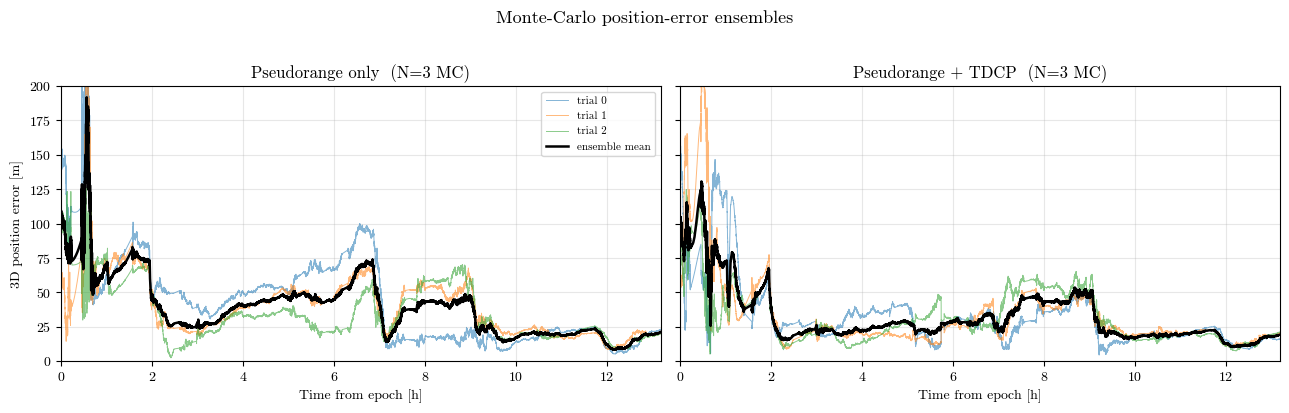

In [14]:
# Ensemble spread: 3D position error vs. time for each MC trial (thin) plus the ensemble mean
# (thick). Left = pseudorange only, right = pseudorange + TDCP. TDCP tightens the spread and
# pulls the whole ensemble down.
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, runs) in zip(axes, mc.items()):
    stack = np.vstack([r["pos_error_m"].to_numpy() for r in runs])
    for i, r in enumerate(runs):
        ax.plot(r["t_hr"], r["pos_error_m"], lw=0.7, alpha=0.55, label=f"trial {i}")
    ax.plot(runs[0]["t_hr"], stack.mean(axis=0), color="k", lw=1.8, label="ensemble mean")
    ax.set_title(f"{label}  (N={len(runs)} MC)")
    ax.set_xlabel("Time from epoch [h]")
    ax.set_xlim(0, runs[0]["t_hr"].max())
    ax.set_ylim(0, 200)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("3D position error [m]")
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Monte-Carlo position-error ensembles", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

variant                trial   RMS pos [m]  final pos [m]
---------------------------------------------------------
Pseudorange only           0         54.62          23.20
Pseudorange only           1         46.90          20.78
Pseudorange only           2         40.30          19.74
Pseudorange only        mean         47.27          21.24
Pseudorange + TDCP         0         39.63          16.07
Pseudorange + TDCP         1         44.04          20.45
Pseudorange + TDCP         2         36.62          20.97
Pseudorange + TDCP      mean         40.10          19.16


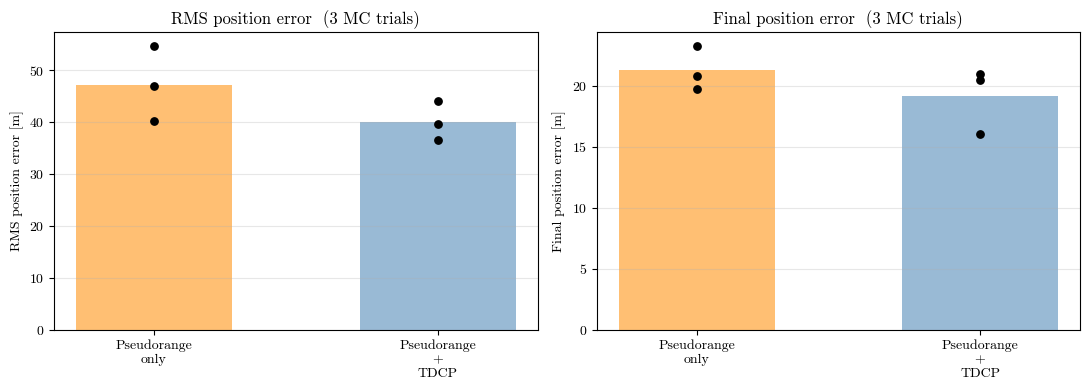

In [15]:
# Head-to-head: RMS and final 3D position error per trial, pseudorange-only vs. + TDCP.
# Bars are the ensemble mean; black dots are the individual MC trials.
metrics = {}
for label, runs in mc.items():
    rms = [float(np.sqrt(np.mean(r["pos_error_m"] ** 2))) for r in runs]
    fin = [float(r["pos_error_m"].iloc[-1]) for r in runs]
    metrics[label] = {"RMS position error": rms, "Final position error": fin}

labels = list(metrics)
print(f"{'variant':22s}{'trial':>6}{'RMS pos [m]':>14}{'final pos [m]':>15}")
print("-" * 57)
for label in labels:
    rms, fin = metrics[label]["RMS position error"], metrics[label]["Final position error"]
    for i, (rr, ff) in enumerate(zip(rms, fin)):
        print(f"{label:22s}{i:>6}{rr:>14.2f}{ff:>15.2f}")
    print(f"{label:22s}{'mean':>6}{np.mean(rms):>14.2f}{np.mean(fin):>15.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(labels))
colors = ["darkorange", "steelblue"]
for ax, mname in zip(axes, ["RMS position error", "Final position error"]):
    means = [np.mean(metrics[l][mname]) for l in labels]
    ax.bar(x, means, width=0.55, color=colors, alpha=0.55)
    for j, l in enumerate(labels):
        ax.scatter([x[j]] * N_MC, metrics[l][mname], color="k", s=28, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels([l.replace(" ", "\n") for l in labels])
    ax.set_ylabel(f"{mname} [m]")
    ax.set_title(f"{mname}  ({N_MC} MC trials)")
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

This notebook demonstrated LuPNT's full lunar-GNSS ODTS pipeline:

- `LunarGnssODTSConfig` defines both truth generation and estimator tuning for a lunar receiver.
- GNSS sidelobe visibility and $C/N_0$ are precomputed once and cached, separating expensive deterministic geometry from repeated filter runs.
- Plasmaspheric delay is ray-traced at anchor epochs and interpolated to the 1 Hz measurement grid.
- Pseudorange uses a dual-frequency ionosphere-free combination when available; Doppler (range rate) constrains velocity and clock drift within each epoch; TDCP defaults to single-frequency (L1) and is handled with stochastic cloning because it couples epochs.
- **TDCP consistency (§7c):** because single-frequency TDCP carries the uncancelled plasma-delay change (RMS ~3.6 cm), its measurement noise must be inflated (`filter_tdcp_noise_inflation_m = 0.20 m`) or the EKF becomes badly overconfident. Ionosphere-free TDCP (`tdcp_ionosphere_free`) cancels the plasma but halves coverage and does not win here, where the binding residual is the frequency-independent broadcast/clock error rather than the plasma.
- The EKF estimates orbit, receiver clock, and the SRP coefficient (`Cr*A/m`) with analytic dynamics sensitivities.